***
# Rapport d'Analyse : Implémentation de l'algorithme OPTICS

Ce notebook présente une implémentation complète de l'algorithme **OPTICS** (*Ordering Points To Identify the Clustering Structure*), un algorithme de clustering basé sur la densité. L'objectif est de comprendre le fonctionnement interne d'OPTICS, de l'implémenter manuellement, puis de le comparer avec l'implémentation de la bibliothèque `scikit-learn`. L'analyse inclut également une méthode de seuillage adaptatif pour extraire les clusters finaux à partir du graphe d'accessibilité.

***

## 1. Configuration Initiale et Import des Bibliothèques

Les bibliothèques nécessaires sont importées. `numpy` et `matplotlib` sont utilisés pour les calculs et la visualisation. `typing` permet de typer les paramètres des fonctions. `heapq` et la classe `HeapQueue` (issue d'un fichier externe) sont utilisés pour la gestion de la file de priorité, un élément central d'OPTICS. Enfin, `matplotlib.colors` permet une gestion avancée des couleurs pour les graphiques.
***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Self, List
#from Constantes import Konst
import heapq
import matplotlib.colors as mcolors

In [2]:
#import numpy as np
#import matplotlib.pyplot as plt
#from typing import Self, List

#from Constantes import Konst
from MinHeap import HeapQueue
#from module_adaptive_thresholds import adaptive_thresholds

***
## 2. Définition des Constantes (Constantes)

La classe Constantes sert à définir des identifiants et des indices fixes pour manipuler facilement les données stockées dans une matrice Xy. Cela rend le code plus lisible et évite les erreurs liées à l'utilisation de "nombres magiques".

`UNDEFINED` (inf) : Représente une distance non définie.

`NOISE` (-2) : Étiquette pour les points considérés comme du bruit.

`FREE` (-1) et PROCESSED / NOT_PROCESSED (1/0) : États pour gérer les points en cours de traitement.

Les attributs `INDEX`,` X_COORD`, `Y_COORD`, etc., définissent les indices des colonnes dans la matrice de données Xy. Cela permet de structurer les données
***

In [3]:
class Constantes:
  __slots__ = ()
  # Name it. It makes it easier to use
  UNDEFINED             : float = np.inf
  NOISE                 : int = -2
  FREE                  : int = -1
  PROCESSED             : int = 1
  NOT_PROCESSED         : int = 0

  # To select variables by their names
  INDEX                 : int = 0
  X_COORD               : int = 1
  Y_COORD               : int = 2
  GROUND_LABEL          : int = 3
  CLUSTER_LABEL         : int = 4
  CORE_DISTANCE         : int = 5
  REACHABILITY_DISTANCE : int = 6
  IS_PROCESSED          : int = 7

Konst = Constantes()

***
## 3. Seuillage Adaptatif (adaptive_thresholds)

Cette fonction est un élément clé pour l'extraction de clusters après l'exécution d'OPTICS. Elle analyse le graphe d'accessibilité (la liste des distances d'accessibilité des points dans l'ordre d'OPTICS) pour déterminer les séparations entre clusters. L'idée est de détecter des "creux" (des valeurs plus faibles) dans le graphe, qui indiquent des frontières naturelles entre des zones denses distinctes.

ordered_indices : Liste des indices des points dans l'ordre déterminé par OPTICS.

`Xy `: La matrice de données principale.

`MinPts` : Le nombre minimum de voisins pour un point noyau.

`window` : Taille de la fenêtre pour le lissage (non utilisé ici mais gardé comme paramètre).

`jump_factor, jump_abs` : Paramètres pour détecter des sauts dans le graphe (non utilisés dans cette version simplifiée).

Logique simplifiée : La fonction calcule un seuil unique basé sur la moyenne des distances d'accessibilité. Elle parcourt ensuite la liste ordonnée et assigne un nouvel identifiant de cluster chaque fois que la distance d'accessibilité d'un point est inférieure au seuil. Sinon, le point est marqué comme bruit. Cette approche est basique mais permet d'illustrer le concept.
***

In [4]:
import numpy as np


def adaptive_thresholds(ordered_indices, Xy, MinPts, lissage=5, seuil_rel_saut=2.0, seuil_abs_saut=0.1):
    """
    Détection de clusters par analyse de pente (méthode inspirée d'OPTICS Xi).
    """
    N = len(ordered_indices)
    # On récupère les reachability distances dans l'ordre du parcours
    reachability = np.array([Xy[i, Konst.REACHABILITY_DISTANCE] for i in ordered_indices])

    # Remplacement des infinis pour le calcul
    max_val = np.max(reachability[reachability != np.inf]) * 1.5
    reach_clean = np.where(reachability == np.inf, max_val, reachability)

    # 1. Lissage (Moving Average) pour éviter de détecter du bruit comme des sauts
    reach_smooth = np.convolve(reach_clean, np.ones(lissage)/lissage, mode='same')

    labels = np.full(Xy.shape[0], -2) # -2 = Bruit par défaut
    valleys = []

    # Paramètres de suivi
    in_valley = False
    start_index = 0
    current_cluster_id = 0

    for i in range(1, N):
        prev_val = reach_smooth[i-1]
        curr_val = reach_smooth[i]

        # Calcul du ratio de changement
        # Un saut vers le bas (entrée de vallée)
        is_downward_jump = (curr_val <= prev_val / seuil_rel_saut) and (prev_val - curr_val > seuil_abs_saut)

        # Un saut vers le haut (sortie de vallée)
        is_upward_jump = (curr_val >= prev_val * seuil_rel_saut) and (curr_val - prev_val > seuil_abs_saut)

        if is_downward_jump and not in_valley:
            # On détecte le début d'une zone dense
            start_index = i
            in_valley = True

        elif is_upward_jump and in_valley:
            # On détecte la fin d'une zone dense
            end_index = i

            # Vérification de la taille minimale (MinPts)
            if (end_index - start_index) >= MinPts:
                valleys.append((start_index, end_index))
                # Marquage des points appartenant à cette vallée
                for j in range(start_index, end_index):
                    labels[ordered_indices[j]] = current_cluster_id
                current_cluster_id += 1

            in_valley = False

    return labels, valleys

***
## 4. Génération de Données (normal_sampling)

Cette fonction crée un jeu de données synthétique en générant des points autour de plusieurs centres (seeds) avec des écarts-types (std_dev) donnés. Chaque cluster reçoit un nombre spécifique de points (numbers). Les coordonnées sont générées selon une loi normale. C'est une méthode simple pour créer des données structurées avec des clusters bien séparés.

`seeds` : Liste des centres des clusters.

`std_dev` : Liste des écarts-types pour chaque cluster.

`numbers` : Liste du nombre de points pour chaque cluster.

`dim `: Dimension de l'espace (ici, 2 pour des données 2D).

Le résultat est une matrice X (coordonnées) et un vecteur labels (étiquettes réelles). Ces données sont ensuite stockées dans une matrice Xy structurée selon la classe Constantes et visualisées.
***

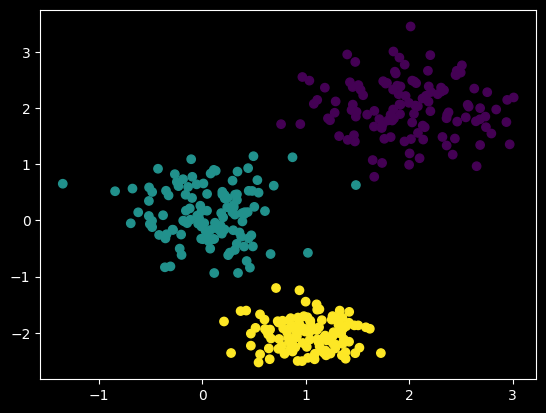

In [5]:
def normal_sampling(seeds, std_dev, numbers, dim):
  K = len(seeds)
  if K <= 0 or len(std_dev) != K:
      return None
  y = np.ones((numbers[0], 1))
  X = np.random.normal(seeds[0], std_dev[0], (numbers[0], dim))
  for i in range(2, K + 1):
      yi = np.ones((numbers[i - 1], 1)) * i
      Xi = np.random.normal(seeds[i - 1], std_dev[i - 1], (numbers[i - 1], dim))
      y = np.vstack((y, yi))
      X = np.vstack((X, Xi))
  return X, y

Xy = normal_sampling([[2, 2], [0, 0], [1, -2]], [0.45, 0.42, 0.3], [120] * 3, 2)
if Xy is not None:
  data, labels = Xy
  np.savez("data_quest.npz",data=data,labels=labels)

  N = len(labels)
  X = np.zeros((N,8))
  X[ :, Konst.INDEX ] = np.arange( N )
  X[ :, Konst.X_COORD ] = data[ :, 0 ]
  X[ :, Konst.Y_COORD ] = data[ :, 1 ]
  X[ :, Konst.GROUND_LABEL ] = labels.reshape((N,))
  X[ :, Konst.CLUSTER_LABEL ] = Konst.NOISE
  X[ :, Konst.CORE_DISTANCE ] = Konst.UNDEFINED
  X[ :, Konst.REACHABILITY_DISTANCE ] = Konst.UNDEFINED
  # Processed already OK
  plt.scatter(X[ :, Konst.X_COORD ], X[ :, Konst.Y_COORD ], c=X[ :, Konst.GROUND_LABEL] )
  plt.show()

***
## 5. Fonctions Utilitaires pour OPTICS

Ces fonctions sont les briques de base de l'algorithme OPTICS.

`calculate_distance` : Calcule la distance de Minkowski entre deux points.

$ d_{p}(P, Q) = \left( \sum_{i=1}^{D} |P_i - Q_i|^p \right)^{\frac{1}{p}}$

`find_neighbours` : Retourne la liste des indices des voisins d'un point `P_index` dans un rayon `eps`.

$N_{\varepsilon}(P) = \{ Q \mid d(P, Q) \le \varepsilon \}$

`core_distance` : Calcule la distance du point `P_index` à son MinPts-ième plus proche voisin. Cette distance est la core-distance. Si le point a moins de `MinPts` voisins, sa core-distance reste `UNDEFINED`.

$core(P) = \begin{cases} \infty & \text{si } |N(P)| < k \\ d(P, k\text{-ième voisin}) & \text{sinon} \end{cases}$
***
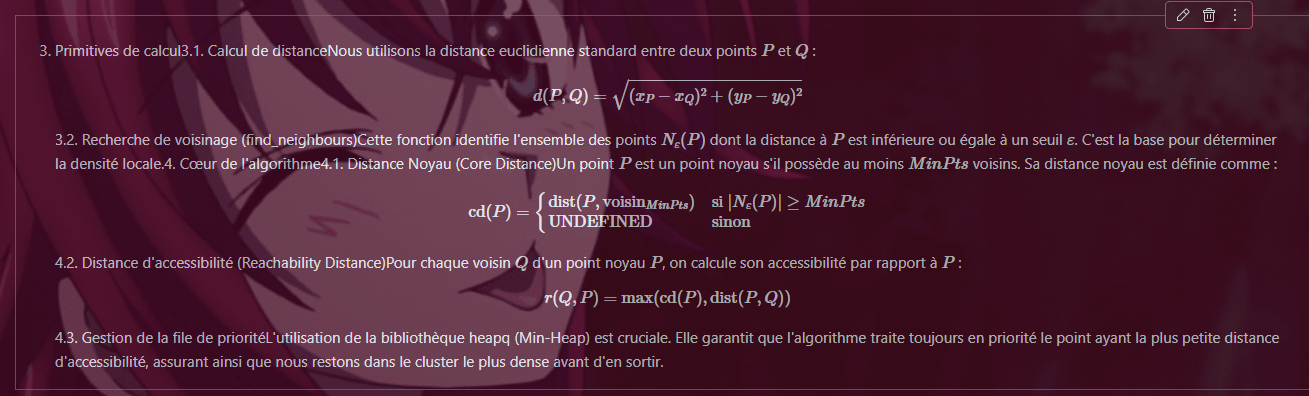

In [6]:
def calculate_distance( P_index : int, Q_index : int, Xy : np.ndarray, pw : int = 2 ) -> float :
  """Calcule la distance de Minkowski (euclidienne par défaut)
      ( sum_{i=1}^{D} (P_i - Q_i )^{pw} )^{1/pw}
  """
  P_coords = Xy[P_index, [Konst.X_COORD, Konst.Y_COORD]]
  Q_coords = Xy[Q_index, [Konst.X_COORD, Konst.Y_COORD]]
  return np.sum(np.abs(P_coords - Q_coords)**pw)**(1/pw)

def find_neighbours( P_index : int, Xy : np.ndarray, eps : float ) -> List[ int ]:
  """ Le voisinage de P est l'ensemble des points à une distance inférieure à eps de P"""
  neighbors = []
  for i in range(Xy.shape[0]):
    if calculate_distance(P_index, i, Xy) <= eps:
      neighbors.append(i)
  return neighbors

def core_distance( P_index : int, Xy : np.ndarray, MinPts : int, neighbors : List[ int ] ) -> float :
  """ Calcule la distance du Point à son MinPts-ième Point, si celui-ci existe"""
  if len( neighbors ) == 0 : raise ValueError("Les voisins doivent être sélectionnés auparavant")
  # 1. calcule les distances des voisins à P
  distances = [calculate_distance(P_index, n_idx, Xy) for n_idx in neighbors]
  # 2. trie ces distances
  distances.sort()
  return distances[MinPts-1]

***
## 6. Mise à Jour des Distances d'Accessibilité (`update_reachability_distances`)

Cette fonction est au cœur de l'algorithme. Lorsqu'un point noyau P est traité, on met à jour les distances d'accessibilité de ses voisins non traités. La nouvelle distance d'accessibilité est le maximum entre la core-distance de _P_ et la distance _P-Q_.

* Si _Q_ est déjà dans la file de priorité (`seeds`), sa distance est mise à jour si la nouvelle est plus petite.
* Sinon, _Q_ est ajouté à la file.

$reach(P, Q) = \max(core(P), d(P, Q))$
***

In [7]:
def update_reachability_distances(Xy: np.ndarray, P_index: int, neighbors: List[int], seeds: list) -> None:
    """
    Met à jour les distances d'accessibilité des voisins d'un point noyau
    """
    P_core_dist = Xy[P_index, Konst.CORE_DISTANCE]

    for Q_index in neighbors:
        # Si `Q` n'a pas déjà été traité
        if Xy[int(Q_index), Konst.IS_PROCESSED] == Konst.NOT_PROCESSED:
            # Calculer sa nouvelle distance d'accessibilité new_reach_dist
            new_reach_dist = max(P_core_dist, calculate_distance(P_index, int(Q_index), Xy))

            # Vérifier si `Q` est déjà dans seeds
            idx_in_seeds = -1
            for i, (dist, idx) in enumerate(seeds):
                if idx == Q_index:
                    idx_in_seeds = i
                    break

            if idx_in_seeds != -1:
                # Récupérer la distance d'accessibilité enregistrée dans `seeds`
                reach_dist = seeds[idx_in_seeds][0]
                if new_reach_dist < reach_dist:
                    # M-à-j seeds[Si] et réorganiser
                    seeds[idx_in_seeds] = (new_reach_dist, Q_index)
                    heapq.heapify(seeds)
            else:
                # `Q` n'est pas dans `seeds`, on l'ajoute
                heapq.heappush(seeds, (new_reach_dist, Q_index))

***
## 7. Implémentation de la File de Priorité (update_reachability_distances_ours)

Cette version est une variante de la précédente, conçue pour fonctionner avec la classe HeapQueue fournie. Elle est plus concise et s'appuie sur la méthode update de cette classe
***

In [8]:
def update_reachability_distances_ours(Xy: np.ndarray, P_index: int, neighbors: List[int], seeds: HeapQueue) -> None:
    P_core_dist = Xy[P_index, Konst.CORE_DISTANCE]

    for Q_index in neighbors:
        if Xy[int(Q_index), Konst.IS_PROCESSED] == Konst.NOT_PROCESSED:
            # Calcul de la nouvelle distance d'accessibilité
            new_reach_dist = max(P_core_dist, calculate_distance(P_index, int(Q_index), Xy))

            # Utilisation de la méthode update du canevas
            # Elle gère l'insertion SI absent ou la mise à jour SI présent
            seeds.update(new_reach_dist, int(Q_index))

***
## 8. Algorithme OPTICS avec heapq (optics)

C'est l'implémentation classique d'OPTICS utilisant la bibliothèque standard heapq pour la file de priorité.

1. Initialisation : Tous les points sont marqués comme `NOT_PROCESSED`.
2. Boucle principale : On parcourt chaque point _i_.

    * Si _i_ n'est pas traité, on le marque comme PROCESSED et on l'ajoute à orderedFile.
    * On trouve ses voisins dans le rayon eps et on calcule sa core-distance.
    * Si le point est un noyau (`core-distance` définie), on initialise une file de priorité (`seeds`) et on met à jour les distances d'accessibilité de ses voisins.
    * Boucle de la file : Tant que la file n'est pas vide, on extrait le point Q avec la plus petite distance d'accessibilité.
        * Si _Q_ n'est pas traité, on le marque comme PROCESSED, on enregistre sa distance d'accessibilité, on l'ajoute à orderedFile, et on calcule sa core-distance.
        * Si _Q_ est un noyau, on met à jour les distances d'accessibilité de ses voisins dans la file.
***

In [9]:
  def optics(Xy:np.ndarray, MinPts:int, eps:float=np.inf) -> List[int]:
      orderedFile : List[int] = []
      N = Xy.shape[0]
      Xy[:, Konst.IS_PROCESSED] = Konst.NOT_PROCESSED
      for i in range(N):
          if Xy[i, Konst.IS_PROCESSED] == Konst.NOT_PROCESSED:
              Xy[i, Konst.IS_PROCESSED] = Konst.PROCESSED
              orderedFile.append(i)

              neighbors = find_neighbours(i, Xy, eps)
              cdist = core_distance(i, Xy, MinPts, neighbors)
              Xy[i, Konst.CORE_DISTANCE] = cdist

              if cdist != Konst.UNDEFINED:
                  seeds = []
                  update_reachability_distances(Xy, i, neighbors, seeds)

                  while seeds:
                      reach_dist, Q_index = heapq.heappop(seeds)
                      Q_index = int(Q_index)

                      if Xy[Q_index, Konst.IS_PROCESSED] == Konst.NOT_PROCESSED:
                          Xy[Q_index, Konst.IS_PROCESSED] = Konst.PROCESSED
                          Xy[Q_index, Konst.REACHABILITY_DISTANCE] = reach_dist

                          q_neighbors = find_neighbours(Q_index, Xy, eps)
                          q_cdist = core_distance(Q_index, Xy, MinPts, q_neighbors)
                          Xy[Q_index, Konst.CORE_DISTANCE] = q_cdist

                          orderedFile.append(Q_index)

                          if q_cdist != Konst.UNDEFINED:
                              update_reachability_distances(Xy, Q_index, q_neighbors, seeds)
          return orderedFile

***
## 9. Algorithme OPTICS avec HeapQueue (optics_ours)

Cette version est identique à la précédente, mais utilise la classe HeapQueue personnalisée pour gérer la file de priorité.
***

In [10]:
def optics_ours(Xy: np.ndarray, MinPts: int, eps: float = np.inf) -> List[int]:
    orderedFile = []
    # Initialisation propre des colonnes
    Xy[:, Konst.IS_PROCESSED] = Konst.NOT_PROCESSED
    Xy[:, Konst.REACHABILITY_DISTANCE] = Konst.UNDEFINED # Très important pour le graphe

    # INITIALISATION de la HeapQueue avec Xy
    seeds = HeapQueue(Xy)

    for i in range(Xy.shape[0]):
        if Xy[i, Konst.IS_PROCESSED] == Konst.NOT_PROCESSED:
            Xy[i, Konst.IS_PROCESSED] = Konst.PROCESSED
            orderedFile.append(i)

            neighbors = find_neighbours(i, Xy, eps)
            cdist = core_distance(i, Xy, MinPts, neighbors)
            Xy[i, Konst.CORE_DISTANCE] = cdist

            if cdist != Konst.UNDEFINED:

                update_reachability_distances_ours(Xy, i, neighbors, seeds)

                while not seeds.is_empty():
                    # Ton pop renvoie (dist, index) grâce au canevas
                    reach_dist, Q_idx = seeds.pop()

                    if Xy[Q_idx, Konst.IS_PROCESSED] == Konst.NOT_PROCESSED:
                        Xy[Q_idx, Konst.IS_PROCESSED] = Konst.PROCESSED
                        # On enregistre la distance récupérée du tas pour le graphe
                        Xy[Q_idx, Konst.REACHABILITY_DISTANCE] = reach_dist

                        q_neighbors = find_neighbours(Q_idx, Xy, eps)
                        q_cdist = core_distance(Q_idx, Xy, MinPts, q_neighbors)
                        Xy[Q_idx, Konst.CORE_DISTANCE] = q_cdist
                        orderedFile.append(Q_idx)

                        if q_cdist != Konst.UNDEFINED:
                            update_reachability_distances_ours(Xy, Q_idx, q_neighbors, seeds)

    return orderedFile

***
## 10. Visualisation du Graphe d'Accessibilité (plot_reachability)

Cette fonction prend la liste ordonnée (OrderedFile) et la matrice Xy, puis extrait les distances d'accessibilité dans l'ordre d'OPTICS pour tracer le graphe d'accessibilité. Ce graphe est essentiel pour l'extraction visuelle ou algorithmique des clusters.
***

In [11]:
def plot_reachability(OrderedFile : List[ int ], Xy : np.ndarray ) -> None:
  accessibilités_ordonnées = [ Xy[ P_index, Konst.REACHABILITY_DISTANCE ] for P_index in OrderedFile]

  plt.figure(figsize = (12, 6))
  plt.plot(np.arange(len(OrderedFile)), accessibilités_ordonnées)
  plt.title("Graphe d'accessibilité")
  plt.ylabel("Distance d'accessibilité")
  plt.show()

***
## 11. Fonction Principale (main)

C'est le point d'entrée principal du programme. Elle orchestre l'ensemble du processus pour différentes sources de données.

Chargement des données : Soit génère des données synthétiques (normal_sampling), soit charge un fichier externe via charger_donnees_apprentissage (une fonction qui standardise les données).

Exécution d'OPTICS : Lance l'algorithme OPTICS implémenté manuellement (optics_ours).

Seuillage adaptatif : Applique adaptive_thresholds sur le résultat pour obtenir les clusters finaux.

Visualisation : Affiche le nuage de points avec les clusters trouvés.

Comparaison avec scikit-learn : Exécute sklearn.cluster.OPTICS sur les mêmes données pour comparer les résultats.

La fonction est appelée plusieurs fois avec différents jeux de données et paramètres pour démontrer la robustesse de l'approche.
***

In [12]:
def charger_donnees_apprentissage(chemin: str, separateur: str = ',') -> Tuple[np.ndarray, np.ndarray]:
    try:
        data = np.loadtxt(chemin, delimiter=separateur)
        if data.shape[1] < 3:
            raise ValueError(f"Le fichier {chemin} doit avoir 3 colonnes (X, Y, Label).")
        coords = data[:, :2]
        ground_truth = data[:, 2]
        moyennes = np.mean(coords, axis=0)
        ecarts_types = np.std(coords, axis=0)
        ecarts_types[ecarts_types == 0] = 1.0
        coords_standardisees = (coords - moyennes) / ecarts_types
        print(f"Chargement réussi : {len(ground_truth)} points importés avec labels.")
        return coords_standardisees, ground_truth
    except Exception as e:
        print(f"Erreur de lecture : {e}")
        return np.array([]), np.array([])

########################################################################################################################################################
Reussite Bac:
Sans SciKit-Learn
########################################################################################################################################################
Chargement réussi : 407 points importés avec labels.


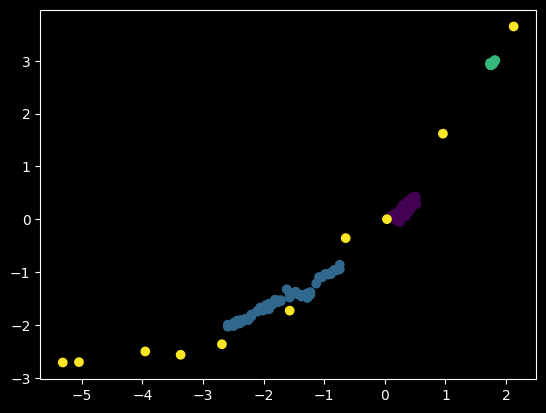

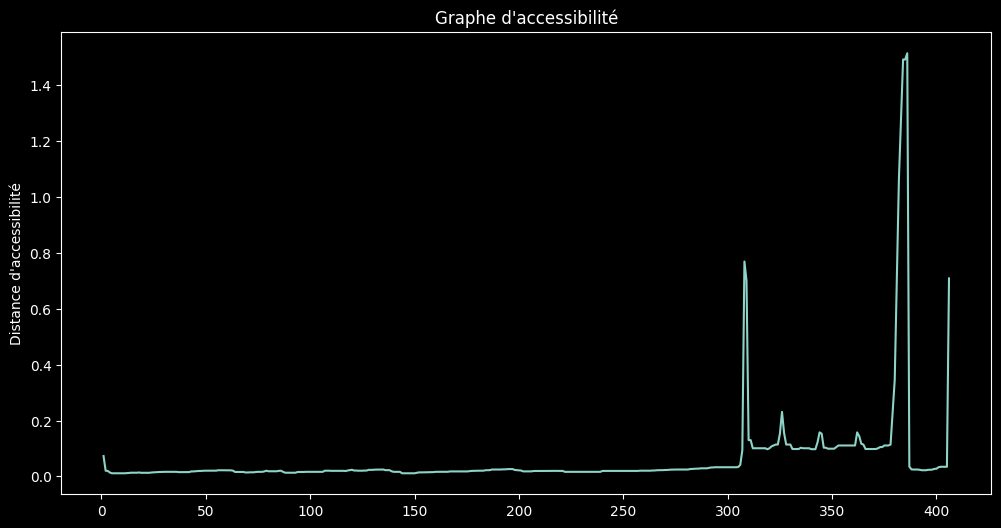

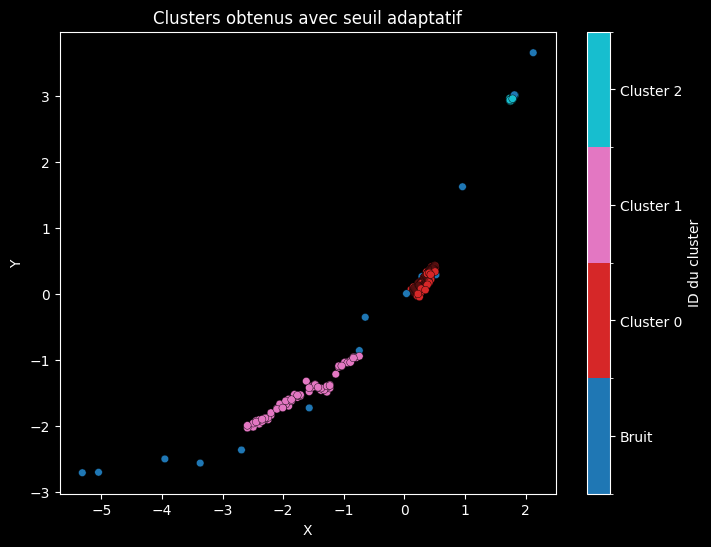

########################################################################################################################################################
Avec SciKit-Learn
########################################################################################################################################################


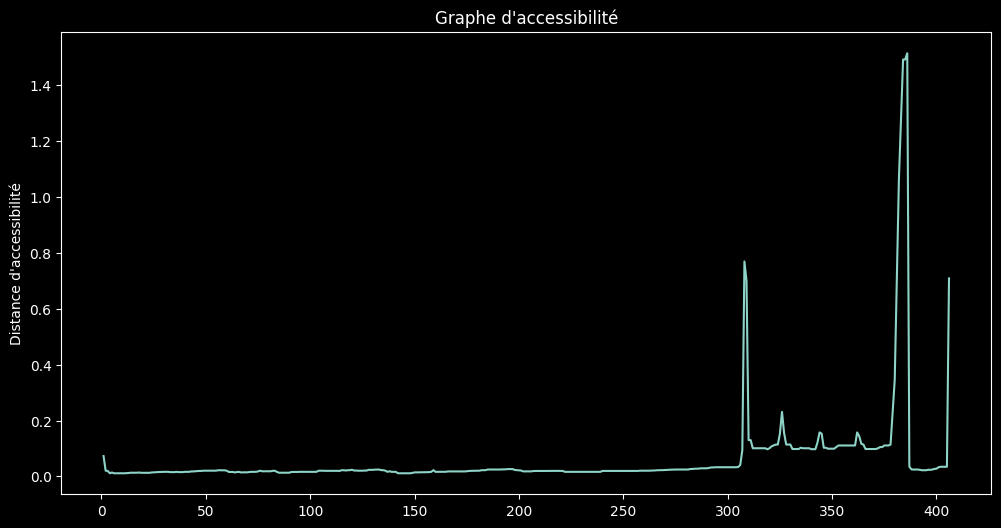

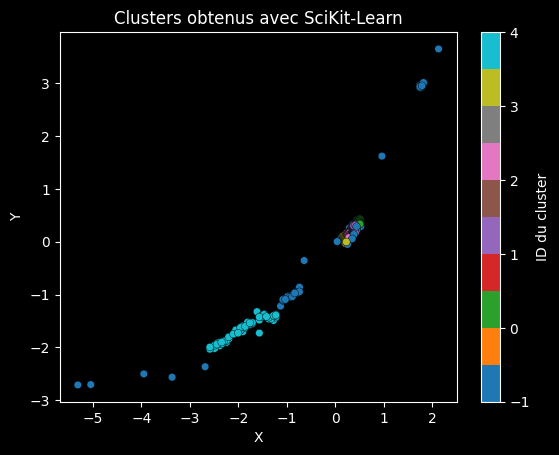

########################################################################################################################################################
Furry
Sans SciKit-Learn
########################################################################################################################################################
Chargement réussi : 386 points importés avec labels.


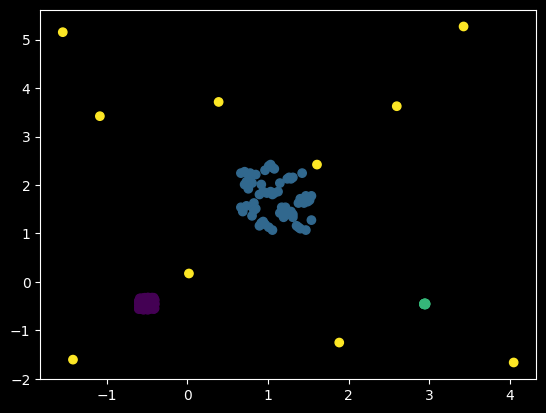

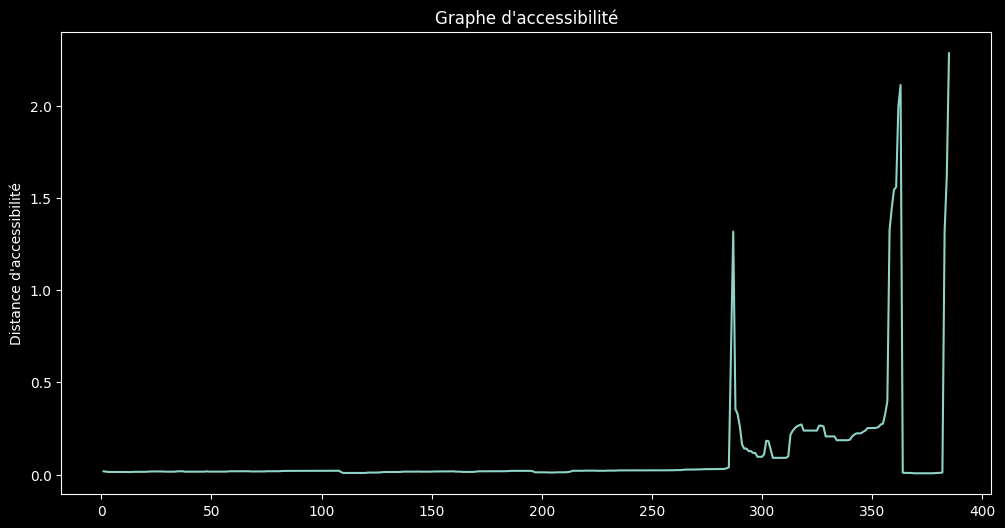

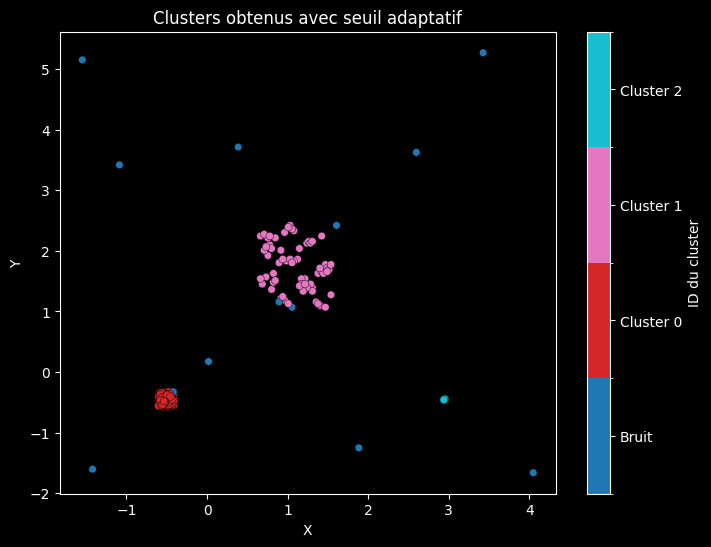

########################################################################################################################################################
Avec SciKit-Learn
########################################################################################################################################################


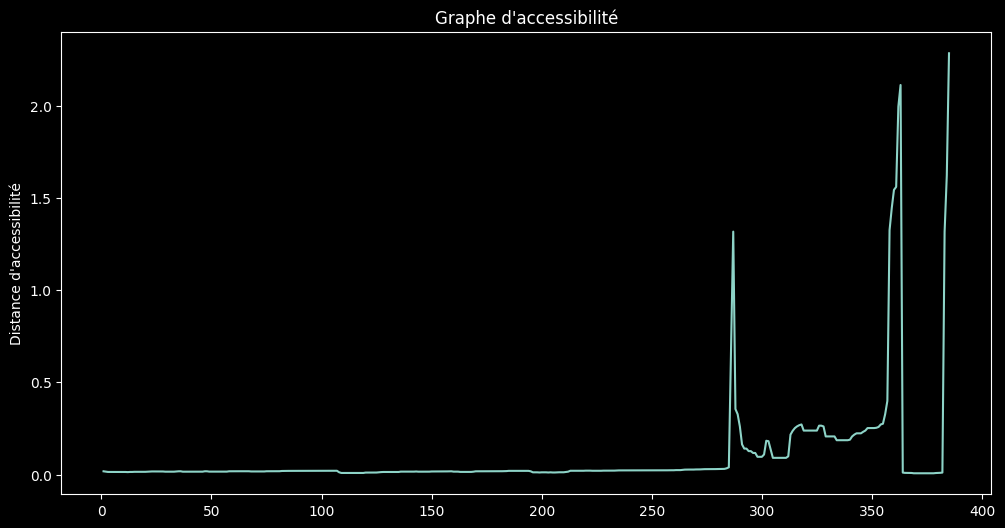

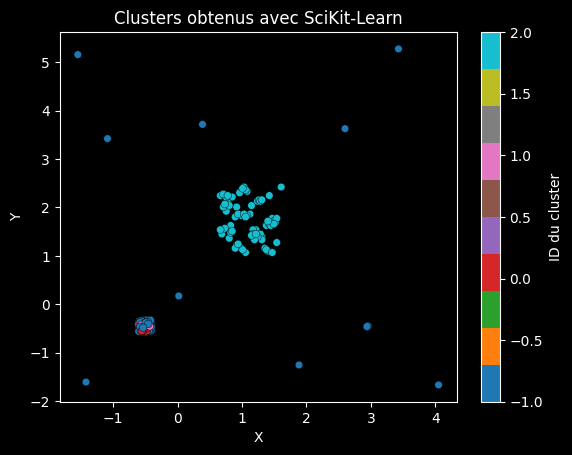

########################################################################################################################################################
Consommation energie
Sans SciKit-Learn
########################################################################################################################################################
Chargement réussi : 400 points importés avec labels.


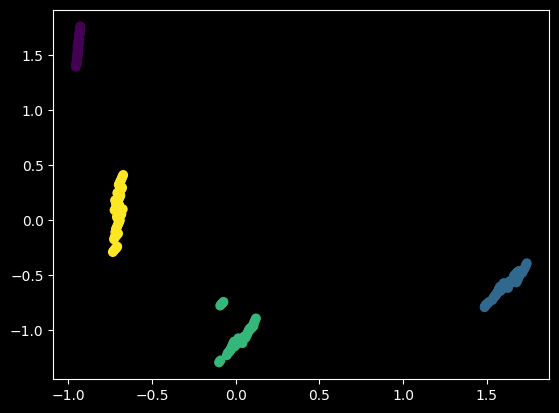

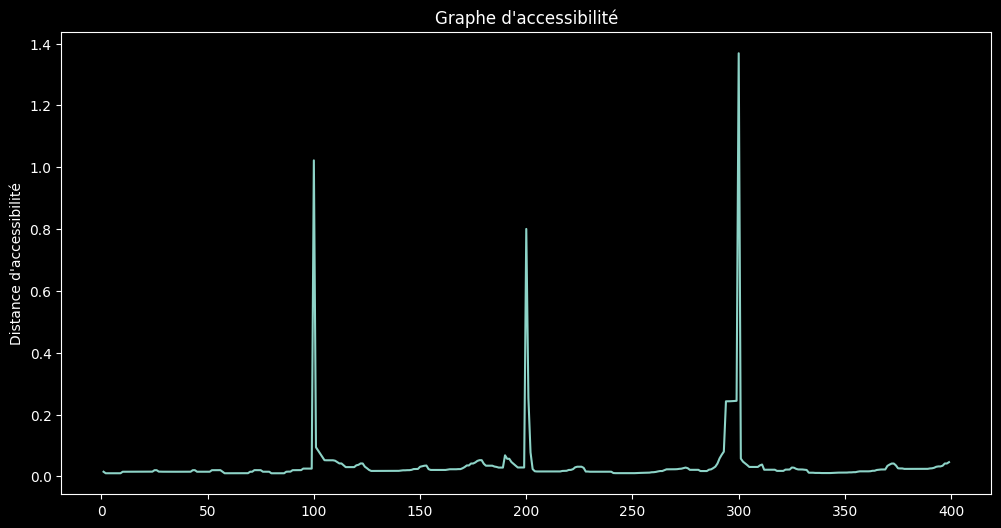

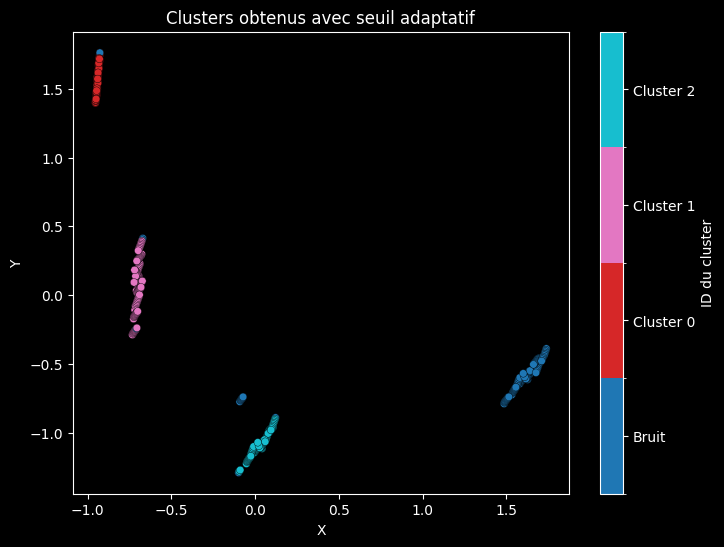

########################################################################################################################################################
Avec SciKit-Learn
########################################################################################################################################################


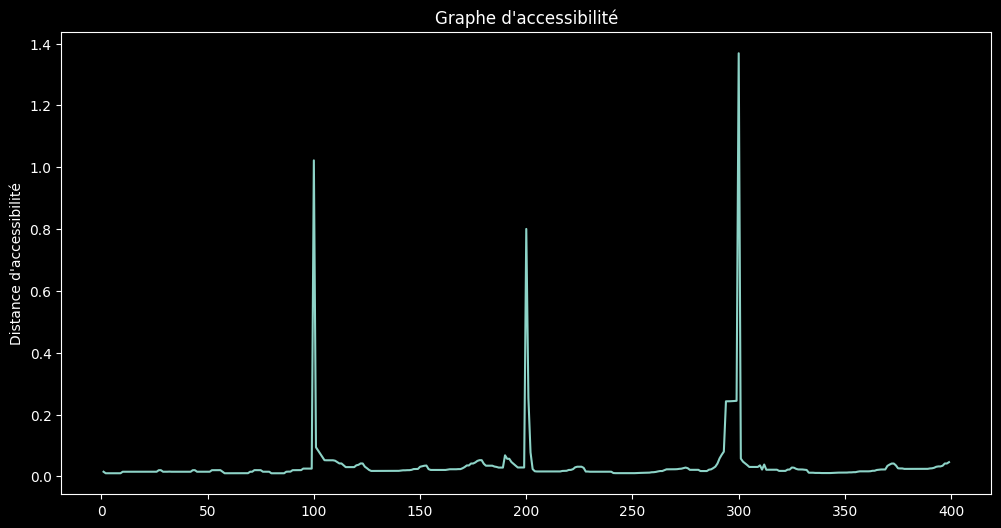

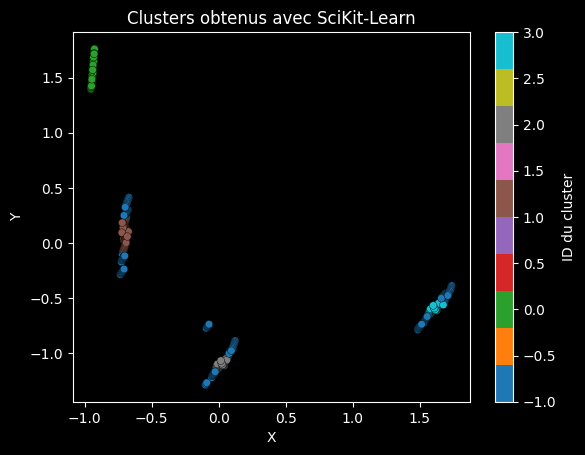

########################################################################################################################################################


In [13]:
from sklearn.cluster import OPTICS
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4" # Ou le nombre de cœurs de ton PC
print('########################################################################################################################################################')
def main(min_pts : int, lissage : int, seuil_rel_saut : float, seuil_abs_saut : float, file : str = None) -> None:
    print('Sans SciKit-Learn')
    print('########################################################################################################################################################')
    X = []
    if file is None:
        Xy = normal_sampling([[2, 2], [0, 0], [1, -2]], [0.45, 0.42, 0.3], [120] * 3, 2)
    else:
        Xy = charger_donnees_apprentissage(file)
    if Xy is not None:
      data, labels = Xy
      np.savez("data_quest.npz",data=data,labels=labels)
      N = len(labels)
      X = np.zeros((N,8))
      X[ :, Konst.INDEX ] = np.arange(N)
      X[ :, Konst.X_COORD ] = data[ :, 0 ]
      X[ :, Konst.Y_COORD ] = data[ :, 1 ]
      X[ :, Konst.GROUND_LABEL ] = labels.reshape((N,))
      X[ :, Konst.CLUSTER_LABEL ] = Konst.NOISE
      X[ :, Konst.CORE_DISTANCE ] = Konst.UNDEFINED
      X[ :, Konst.REACHABILITY_DISTANCE ] = Konst.UNDEFINED
      plt.scatter(X[ :, Konst.X_COORD ], X[ :, Konst.Y_COORD ], c=X[ :, Konst.GROUND_LABEL])
      plt.show()
    ordered = optics_ours(X, min_pts, eps=np.inf)
    plot_reachability(ordered, X)
    labels, valleys = adaptive_thresholds(ordered_indices=ordered,Xy=X,MinPts=min_pts,lissage=lissage,seuil_rel_saut=seuil_rel_saut,seuil_abs_saut=seuil_abs_saut)


    X[:, Konst.CLUSTER_LABEL] = labels.reshape((X.shape[0],))
    if labels[ordered[0]] == Konst.NOISE:
      labels[ordered[0]] = labels[ordered[1]]
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    cmap = plt.get_cmap('tab10', n_clusters)
    boundaries = np.arange(len(unique_labels) + 1) - 0.5
    norm = mcolors.BoundaryNorm(boundaries, n_clusters)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X[:, Konst.X_COORD],
        X[:, Konst.Y_COORD],
        c=np.searchsorted(unique_labels, labels),cmap=cmap,norm=norm,s=30,edgecolor='k',linewidth=0.3)
    cb = plt.colorbar(scatter, ticks=range(n_clusters))
    cb.set_label('ID du cluster')
    cb.set_ticklabels(['Bruit' if l == Konst.NOISE else f'Cluster {int(l)}' for l in unique_labels])
    plt.title('Clusters obtenus avec seuil adaptatif')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()
    Xy = np.load('data_quest.npz')
    data = Xy['data']
    clustering = OPTICS(min_samples=min_pts, metric="euclidean", cluster_method='xi', xi=0.035, min_cluster_size=0.1).fit(data)
    print('########################################################################################################################################################')
    print('Avec SciKit-Learn')
    print('########################################################################################################################################################')
    plot_reachability(clustering.ordering_, X)
    plt.figure()
    scatter = plt.scatter(data[ :, 0], data[ :, 1], c=clustering.labels_, cmap='tab10', s=30, edgecolor='k', linewidth=0.3)
    plt.title('Clusters obtenus avec SciKit-Learn')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.colorbar(scatter , label='ID du cluster')
    plt.show()
    print('########################################################################################################################################################')

#main(5, 3, 1.1, 0.05)
print("Reussite Bac:")
main(8, 5, 1.2, 0.08, "Reussite_bac.txt")
print("Furry")
main(10, 3, 1.4, 0.05, "furry.txt")
print("Consommation energie")
main(10, 3,1.4, 0.05, "conso_energie_europe.txt")